# 03 – Forecasting Models: Single-Plant, Single-Day Day-Ahead Setup

Dieses Notebook simuliert den realen Bidding-Alltag: Für jeden Zieltag wird mit den 30 Tagen davor neu trainiert und ein 24h-Day-Ahead-Forecast erzeugt.

## Zwei Szenarien

| Szenario | Features | Beschreibung |
|---|---|---|
| **Historical** | SCADA-Lags (lag_24/48, Rolling Means, Zeitfeatures) | Nur historische Produktionsdaten, keine Wettervorhersage |
| **NWP** | NWP-Vorhersage + SCADA-Lags | Echte Wettervorhersagedaten (Wind 100m, Temperatur, Druck, Bewölkung) als Hauptfeature |

## Designentscheidungen

**Ein Standort:** Schonungen — längste verfügbare Zeitreihe (2014–2025).

**Rolling Retraining:** Für jeden Zieltag wird mit den 30 Tagen davor neu trainiert (kein Blick in die Zukunft). Das simuliert den realen Day-Ahead-Bidding-Prozess.

**Zufällige Zieltage:** N zufällig gezogene Tage nach 2017-02-05 (NWP-Datenverfügbarkeit), alle mit vollständigen 24 Stunden und ausreichend Trainingsdaten. Reproduzierbar über `RANDOM_SEED=42`.

## 1. Setup und Imports

In [15]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FORECAST_DIR  = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"

for d in [FORECAST_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from src.models import elastic_net
from src.models import random_forest
from src.models import gradient_boosting
from src.models import xgboost_model
from src.models import quantile_regression
from src.models import quantile_regression_forest
from src.models import quantile_gradient_boosting
from src.models import quantile_xgboost
from src.models import arima

from src.data.load_nwp import load_and_merge_nwp, FEATURES_HISTORICAL, FEATURES_NWP

print("Project root:", PROJECT_ROOT)


Project root: /Users/noahweis/wind_bidding_project


## 2. Parameter

In [27]:
SELECTED_PLANT       = "Schonungen"
TRAINING_WINDOW_DAYS = 30
HORIZON_HOURS        = 24
QUANTILES            = [0.10, 0.25, 0.50, 0.75, 0.90]
N_TARGET_DAYS        = 60    # Anzahl zufälliger Zieltage
RANDOM_SEED          = 42

FIGURES_DIR  = PROJECT_ROOT / "results" / "figures"
TABLES_DIR   = PROJECT_ROOT / "results" / "tables"
FORECAST_DIR = PROJECT_ROOT / "results" / "forecasts"

for d in [FIGURES_DIR, TABLES_DIR, FORECAST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Zwei Szenarien: mit und ohne NWP-Wettervorhersagedaten
from src.data.load_nwp import load_and_merge_nwp, FEATURES_HISTORICAL, FEATURES_NWP
SCENARIOS = {
    "historical": FEATURES_HISTORICAL,
    "nwp":        FEATURES_NWP,
}

print(f"Standort: {SELECTED_PLANT}")
print(f"Trainingsfenster: {TRAINING_WINDOW_DAYS} Tage")
print(f"Zieltage (zufällig): {N_TARGET_DAYS}")

Standort: Schonungen
Trainingsfenster: 30 Tage
Zieltage (zufällig): 60


## 3. Daten laden und Standort filtern

In [17]:
df_all = pd.read_csv(PROCESSED_DIR / "final_dataset.csv", parse_dates=["timestamp"])

df = df_all[df_all["site"] == SELECTED_PLANT].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Datensatz für {SELECTED_PLANT}: {df.shape}")
print(f"Zeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")

# Lückenprüfung
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing = full_range.difference(df["timestamp"])
print(f"Fehlende Stunden: {len(missing)} von {len(full_range)}")

Datensatz für Schonungen: (98357, 11)
Zeitraum: 2014-01-02 00:00:00 bis 2025-08-31 23:00:00
Fehlende Stunden: 3883 von 102240


## 4. Feature Engineering — NACH dem Standort-Filter

Erst filtern, dann Lags bauen — sonst könnten Lags von anderen Standorten stammen.

In [18]:
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Baut Day-Ahead-konforme Lag-Features. Nur Informationen die
    24h vor der Zielstunde bereits verfügbar wären.
    """
    df = df.copy()
    df["energy_lag_24"]     = df["power"].shift(24)
    df["energy_lag_48"]     = df["power"].shift(48)
    df["wind_speed_lag_24"] = df["wind_speed"].shift(24)
    df["energy_roll_mean_72"]  = df["power"].shift(24).rolling(72).mean()
    df["wind_roll_mean_72"]    = df["wind_speed"].shift(24).rolling(72).mean()
    return df

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "timestamp" not in df.columns:
        raise ValueError("timestamp column is required to create time features")
    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df

df = add_lag_features(df)
df = add_time_features(df)

TARGET = "power"

# NWP-Daten einmergen (lag_0 = echte Vorhersage fuer Zielstunde)
df = load_and_merge_nwp(df, site=SELECTED_PLANT)

# Alle benoetigten Features aus beiden Szenarien fuer dropna nutzen
ALL_FEATURES = list(set(FEATURES_HISTORICAL + FEATURES_NWP))

df_model = df.dropna(subset=ALL_FEATURES + [TARGET]).reset_index(drop=True)
print(f"Nach Lag-Feature-Erstellung, NWP-Merge und Dropna: {df_model.shape}")
print(f"NWP-Daten vorhanden: {df_model['nwp_ws100'].notna().sum()} Stunden")


NWP geladen (Schonungen): 75,960 Stunden | 2017-01-01 bis 2025-08-31
Nach Lag-Feature-Erstellung, NWP-Merge und Dropna: (75129, 24)
NWP-Daten vorhanden: 75129 Stunden


/Users/noahweis/wind_bidding_project/src/data/load_nwp.py:213: UserWarning: 23228 Stunden ohne NWP-Daten (23.6%).
  warnings.warn(


## 5. Zufällige Tagesauswahl

N Tage werden zufällig gezogen. Bedingungen:
- Datum nach 2017-02-05 (NWP-Daten verfügbar)
- Vollständige 24 Stunden im Dataset
- Mind. 30 Tage Trainingsdaten im Dataset vorhanden

Verfügbare vollständige Tage (nach NWP-Start): 3070
Ausgewählte Zieltage: 60
Zeitraum: 2017-03-03 bis 2025-07-30


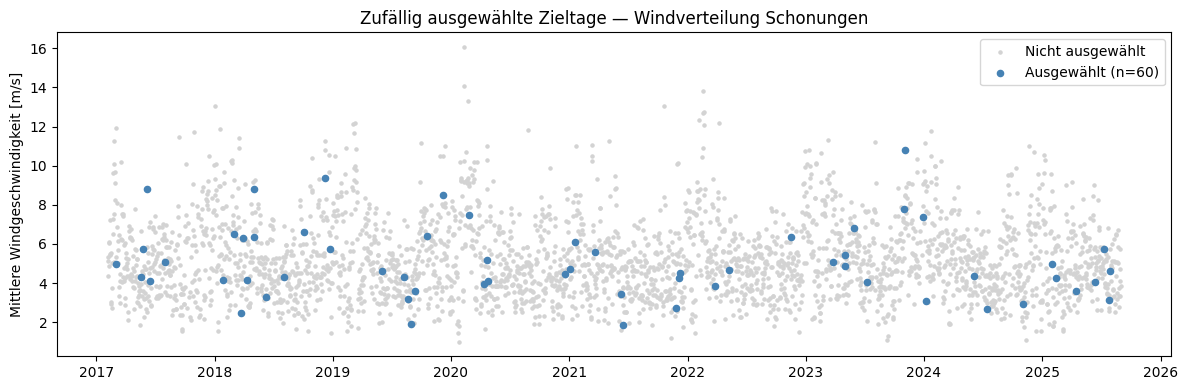

Wind-Stats: Mittel=5.04 | Std=1.86 | Min=1.85 | Max=10.78


In [19]:
import random

NWP_START = pd.Timestamp("2017-02-05")

# Alle vollständigen Tage nach NWP_START
df_tmp = df[df["timestamp"] >= NWP_START].copy()
df_tmp["date"] = df_tmp["timestamp"].dt.date
daily_counts = df_tmp.groupby("date")["timestamp"].count()
full_days = daily_counts[daily_counts >= 24].index.tolist()

# Nur Tage mit mind. 30 Tagen Trainingsdaten davor im df_model
valid_days = [
    d for d in full_days
    if pd.Timestamp(d) - pd.Timedelta(days=30) >= df_model["timestamp"].min()
]

random.seed(RANDOM_SEED)
selected = sorted(random.sample(valid_days, min(N_TARGET_DAYS, len(valid_days))))
TARGET_DAYS = {str(d): str(d) for d in selected}

print(f"Verfügbare vollständige Tage (nach NWP-Start): {len(valid_days)}")
print(f"Ausgewählte Zieltage: {len(TARGET_DAYS)}")
print(f"Zeitraum: {selected[0]} bis {selected[-1]}")

# Windverteilung der ausgewählten Tage
df_tmp2 = df[df["timestamp"] >= NWP_START].copy()
df_tmp2["date"] = df_tmp2["timestamp"].dt.date
daily_wind = df_tmp2.groupby("date")["wind_speed"].mean().reset_index()
daily_wind.columns = ["date", "mean_wind_speed"]
daily_wind["date"] = pd.to_datetime(daily_wind["date"])
daily_wind["selected"] = daily_wind["date"].dt.strftime("%Y-%m-%d").isin(TARGET_DAYS.keys())

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(
    daily_wind[~daily_wind["selected"]]["date"],
    daily_wind[~daily_wind["selected"]]["mean_wind_speed"],
    s=5, color="lightgray", label="Nicht ausgewählt", zorder=1
)
ax.scatter(
    daily_wind[daily_wind["selected"]]["date"],
    daily_wind[daily_wind["selected"]]["mean_wind_speed"],
    s=20, color="steelblue", label=f"Ausgewählt (n={len(TARGET_DAYS)})", zorder=2
)
ax.set_ylabel("Mittlere Windgeschwindigkeit [m/s]")
ax.set_title(f"Zufällig ausgewählte Zieltage — Windverteilung Schonungen")
ax.legend()
plt.tight_layout()
plt.show()

sel_wind = daily_wind[daily_wind["selected"]]["mean_wind_speed"]
print(f"Wind-Stats: Mittel={sel_wind.mean():.2f} | Std={sel_wind.std():.2f} | Min={sel_wind.min():.2f} | Max={sel_wind.max():.2f}")

## 6. Rolling-Training-Funktionen

In [20]:
def get_train_test_window(
    df_model: pd.DataFrame,
    target_day: str,
    window_days: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (train_df, test_df) für einen Zieltag zurück.
    train_df: die window_days Tage VOR dem Zieltag.
    test_df:  die 24 Stunden DES Zieltags.
    """
    target_start = pd.Timestamp(target_day)
    target_end   = target_start + pd.Timedelta(hours=23)
    train_start  = target_start - pd.Timedelta(days=window_days)
    train_end    = target_start - pd.Timedelta(hours=1)

    train_df = df_model[
        (df_model["timestamp"] >= train_start) & (df_model["timestamp"] <= train_end)
    ].copy()
    test_df = df_model[
        (df_model["timestamp"] >= target_start) & (df_model["timestamp"] <= target_end)
    ].copy()

    return train_df, test_df


# Sanity-Check mit einem der neuen Keys
_first_key = list(TARGET_DAYS.keys())[0]
_train_check, _test_check = get_train_test_window(df_model, TARGET_DAYS[_first_key], window_days=30)
print(f"Beispieltag: {_first_key} → {TARGET_DAYS[_first_key]}")
print(f"Train: {len(_train_check)} Stunden ({_train_check['timestamp'].min()} bis {_train_check['timestamp'].max()})")
print(f"Test:  {len(_test_check)} Stunden ({_test_check['timestamp'].min()} bis {_test_check['timestamp'].max()})")

Beispieltag: 2017-03-03 → 2017-03-03
Train: 720 Stunden (2017-02-01 00:00:00 bis 2017-03-02 23:00:00)
Test:  24 Stunden (2017-03-03 00:00:00 bis 2017-03-03 23:00:00)


In [21]:
# Sanity-Check
_first_key = list(TARGET_DAYS.keys())[0]
_train_check, _test_check = get_train_test_window(df_model, TARGET_DAYS[_first_key], window_days=30)
print(f"Beispieltag: {_first_key}")
print(f"Train: {len(_train_check)} Stunden ({_train_check['timestamp'].min()} bis {_train_check['timestamp'].max()})")
print(f"Test:  {len(_test_check)} Stunden ({_test_check['timestamp'].min()} bis {_test_check['timestamp'].max()})") 

Beispieltag: 2017-03-03
Train: 720 Stunden (2017-02-01 00:00:00 bis 2017-03-02 23:00:00)
Test:  24 Stunden (2017-03-03 00:00:00 bis 2017-03-03 23:00:00)


## 7. Modelle trainieren und Forecasts erzeugen

In [22]:
def run_single_day(target_day: str, day_label: str, window_days: int, scenario: str = "historical") -> pd.DataFrame:
    """
    Trainiert alle Modelle auf den TRAINING_WINDOW_DAYS Tagen vor target_day
    und erzeugt 24h-Forecasts für target_day.

    Returns
    -------
    pd.DataFrame mit einer Zeile pro Stunde des Zieltags und einer Spalte
    pro Modell/Quantil.
    """
    train_df, test_df = get_train_test_window(df_model, target_day, window_days=window_days)

    if len(test_df) < HORIZON_HOURS:
        warnings.warn(f"{day_label}: nur {len(test_df)} Stunden im Testfenster, erwartet {HORIZON_HOURS}.")
    if len(train_df) < window_days * 24 * 0.8:
        warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")

    features = SCENARIOS[scenario]
    X_train, y_train = train_df[features], train_df[TARGET]
    X_test,  y_test  = test_df[features],  test_df[TARGET]

    result = pd.DataFrame({
        "timestamp": test_df["timestamp"].values,
        "day_label": day_label,
        "window_days": window_days,
        "scenario": scenario,
        "y_true": y_test.values,
    })

    # --- Persistence 24h ---
    result["persistence_24h"] = X_test["energy_lag_24"].to_numpy()

    # --- Elastic Net ---
    en_model = elastic_net.train(X_train, y_train)
    result["elastic_net"] = elastic_net.predict(en_model, X_test, clip_negative=True)

    # --- Random Forest ---
    # Bei nur ~720 Trainingsstunden braucht der Wald weniger, flachere Baeume
    # mit kleinerem min_samples_leaf, sonst kollabieren die Vorhersagen auf
    # wenige Blattwerte (zu starke Regularisierung fuer so wenig Daten).
    # Komplexität skaliert leicht mit der Trainingsfenstergröße:
    # bei 90 Tagen (mehr Daten) sind tiefere Bäume robuster moeglich als bei 30 Tagen.
    rf_max_depth = 6 if window_days <= 30 else 8
    rf_model = random_forest.train(
        X_train, y_train,
        n_estimators=200, max_depth=rf_max_depth, min_samples_leaf=2,
        random_state=42,
    )
    result["random_forest"] = random_forest.predict(rf_model, X_test, clip_negative=True)

    # --- Gradient Boosting ---
    gb_max_depth = 3 if window_days <= 30 else 4
    gb_model = gradient_boosting.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=gb_max_depth, min_samples_leaf=3,
        random_state=42,
    )
    result["gradient_boosting"] = gradient_boosting.predict(gb_model, X_test, clip_negative=True)

    # --- XGBoost ---
    xgb_max_depth = 3 if window_days <= 30 else 4
    xgb_model = xgboost_model.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=xgb_max_depth, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    result["xgboost"] = xgboost_model.predict(xgb_model, X_test, clip_negative=True)

    # --- ARIMA (nur Zielreihe) ---
    # Nutzt eure eigene arima.py: train() schaetzt (p,d,q) automatisch via auto_arima
    # (Fallback auf festen Default falls pmdarima nicht installiert ist).
    try:
        arima_fitted = arima.train(y_train.to_numpy())
        y_pred_arima = arima.predict(arima_fitted, steps=len(y_test))
        result["arima"] = np.clip(y_pred_arima, 0, None)
    except Exception as e:
        warnings.warn(f"{day_label}: ARIMA fehlgeschlagen ({e}), fülle mit NaN.")
        result["arima"] = np.nan

    # --- Quantile Regression ---
    qr_models = quantile_regression.train(X_train, y_train, quantiles=QUANTILES)
    qr_preds  = quantile_regression.predict_all(qr_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"quantile_regression_{col}"] = qr_preds[col].values

    # --- QRF ---
    qrf_model = quantile_regression_forest.train(X_train, y_train, random_state=42)
    qrf_preds = quantile_regression_forest.predict_all(qrf_model, X_test, quantiles=QUANTILES, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qrf_{col}"] = qrf_preds[col].values

    # --- QGB ---
    qgb_models = quantile_gradient_boosting.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_samples_leaf=3,
        random_state=42,
    )
    qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qgb_{col}"] = qgb_preds[col].values

    # --- Quantile XGBoost ---
    qxgb_models = quantile_xgboost.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    qxgb_preds = quantile_xgboost.predict_all(qxgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qxgb_{col}"] = qxgb_preds[col].values

    return result

## 8. Alle 60 Zieltage durchlaufen

Je 2 Szenarien × 60 Tage = 120 Trainingsdurchläufe.

In [23]:
all_results = []

for scenario in SCENARIOS:
    print(f"\n{'='*60}")
    print(f"SZENARIO: {scenario.upper()} | FENSTER: {TRAINING_WINDOW_DAYS} Tage")
    print(f"{'='*60}")

    for day_label, target_day in TARGET_DAYS.items():
        try:
            day_result = run_single_day(
                target_day, day_label,
                window_days=TRAINING_WINDOW_DAYS,
                scenario=scenario,
            )
            all_results.append(day_result)
        except Exception as e:
            warnings.warn(f"{day_label} ({scenario}): {e}")

predictions_single_day = pd.concat(all_results, ignore_index=True)
print(f"\nGesamt: {predictions_single_day.shape}")
print(f"Stunden pro Szenario: {len(predictions_single_day) // len(SCENARIOS)}")


SZENARIO: HISTORICAL | FENSTER: 30 Tage


/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_73776/2459222490.py:16: UserWarning: 2023-12-30: nur 553 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")
/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_73776/2459222490.py:16: UserWarning: 2024-01-06: nur 553 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")



SZENARIO: NWP | FENSTER: 30 Tage


/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_73776/2459222490.py:16: UserWarning: 2023-12-30: nur 553 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")
/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_73776/2459222490.py:16: UserWarning: 2024-01-06: nur 553 Trainingsstunden, erwartet ~720.
  warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")



Gesamt: (2880, 31)
Stunden pro Szenario: 1440


## 9. Speichern für Notebook 04

In [24]:
predictions_single_day.to_csv(FORECAST_DIR / "predictions_single_day.csv", index=False)
print(f"Gespeichert: predictions_single_day.csv ({predictions_single_day.shape})")

Gespeichert: predictions_single_day.csv ((2880, 31))


## 10. Forecast-Metriken

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

POINT_MODEL_COLS = ["persistence_24h", "elastic_net", "random_forest", "gradient_boosting", "xgboost", "arima"]

point_metrics_rows = []
for (scenario, window_days), grp in predictions_single_day.groupby(["scenario", "window_days"]):
    for col in POINT_MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() == 0:
            continue
        y_t = grp.loc[valid, "y_true"].values
        y_p = grp.loc[valid, col].values
        bias = float(np.mean(y_p - y_t))
        point_metrics_rows.append({
            "scenario":    scenario,
            "window_days": window_days,
            "model":       col,
            "MAE":         round(mean_absolute_error(y_t, y_p), 4),
            "RMSE":        round(np.sqrt(mean_squared_error(y_t, y_p)), 4),
            "R2":          round(r2_score(y_t, y_p), 4),
            "Bias":        round(bias, 2),
            "Bias_pct":    round(bias / float(np.mean(y_t)) * 100, 2),
        })

point_metrics_single_day = pd.DataFrame(point_metrics_rows).sort_values(["scenario", "RMSE"])
point_metrics_single_day.to_csv(TABLES_DIR / "point_forecast_metrics_single_day.csv", index=False)
display(point_metrics_single_day)

,scenario,window_days,model,MAE,RMSE,R2,Bias,Bias_pct
5,historical,30,arima,315.4185,430.7689,0.0912,86.72,24.69
4,historical,30,xgboost,344.6457,488.3333,-0.1680,32.44,9.24
1,historical,30,elastic_net,345.7419,491.7816,-0.1845,29.70,8.46
2,historical,30,random_forest,345.0005,491.8944,-0.1851,50.26,14.31
3,historical,30,gradient_boosting,353.6895,492.7222,-0.1890,39.49,11.25
0,historical,30,persistence_24h,389.2847,585.1656,-0.6771,61.16,17.42
7,nwp,30,elastic_net,172.4759,258.2153,0.6734,23.13,6.59
10,nwp,30,xgboost,168.9504,265.7853,0.6540,-0.91,-0.26
9,nwp,30,gradient_boosting,170.2703,266.3632,0.6525,2.41,0.69
8,nwp,30,random_forest,170.3651,271.9712,0.6377,-0.25,-0.07


## 11. Szenariovergleich: Historical vs. NWP

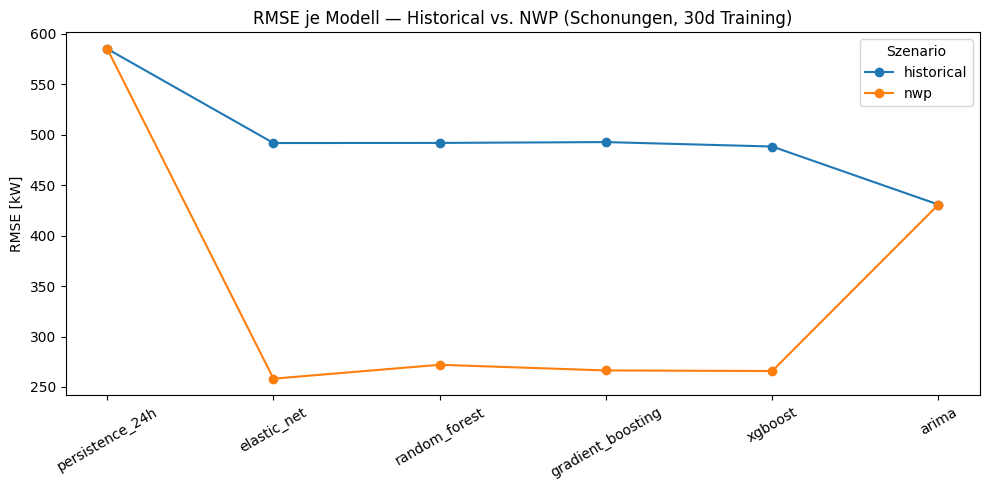

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

for scenario, grp in point_metrics_single_day.groupby("scenario"):
    grp_sorted = grp.set_index("model").reindex(POINT_MODEL_COLS).dropna()
    ax.plot(grp_sorted.index, grp_sorted["RMSE"], marker="o", label=scenario)

ax.set_ylabel("RMSE [kW]")
ax.set_title(f"RMSE je Modell — Historical vs. NWP ({SELECTED_PLANT}, {TRAINING_WINDOW_DAYS}d Training)")
ax.legend(title="Szenario")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scenario_rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Quantile-Band-Plot (Beispieltag)

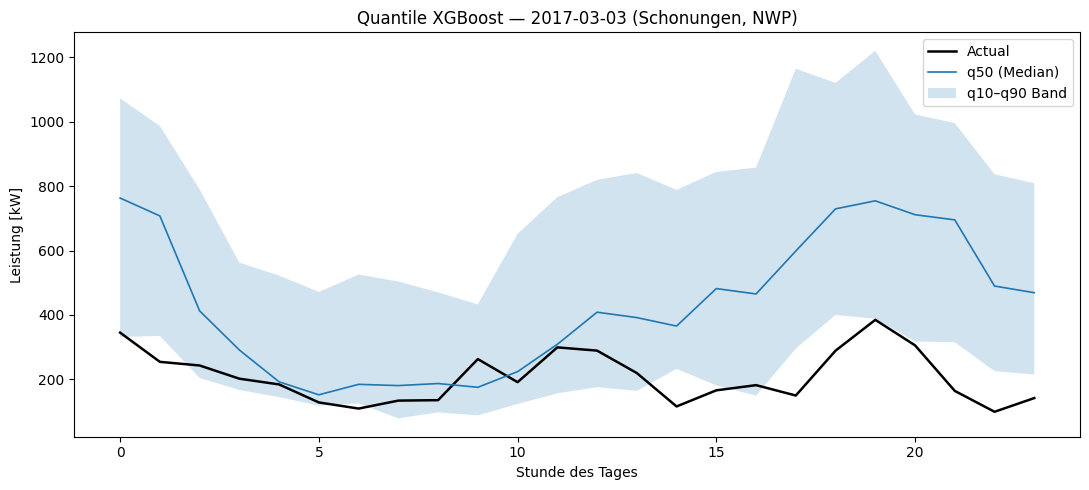

In [29]:
PLOT_DAY          = list(TARGET_DAYS.keys())[0]
PLOT_MODEL_PREFIX = "qxgb"
PLOT_SCENARIO     = "nwp"

day_data = predictions_single_day[
    (predictions_single_day["day_label"] == PLOT_DAY) &
    (predictions_single_day["scenario"]  == PLOT_SCENARIO)
].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(day_data)), day_data["y_true"], label="Actual", color="black", linewidth=1.8)
ax.plot(range(len(day_data)), day_data[f"{PLOT_MODEL_PREFIX}_q50"], label="q50 (Median)", linewidth=1.2)
ax.fill_between(
    range(len(day_data)),
    day_data[f"{PLOT_MODEL_PREFIX}_q10"],
    day_data[f"{PLOT_MODEL_PREFIX}_q90"],
    alpha=0.2, label="q10–q90 Band",
)
ax.set_title(f"Quantile XGBoost — {PLOT_DAY} ({SELECTED_PLANT}, NWP)")
ax.set_ylabel("Leistung [kW]")
ax.set_xlabel("Stunde des Tages")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"quantile_band_{PLOT_DAY}.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Forecast vs. Actual — Übersicht

Zeigt die ersten 12 Zieltage im NWP-Szenario.

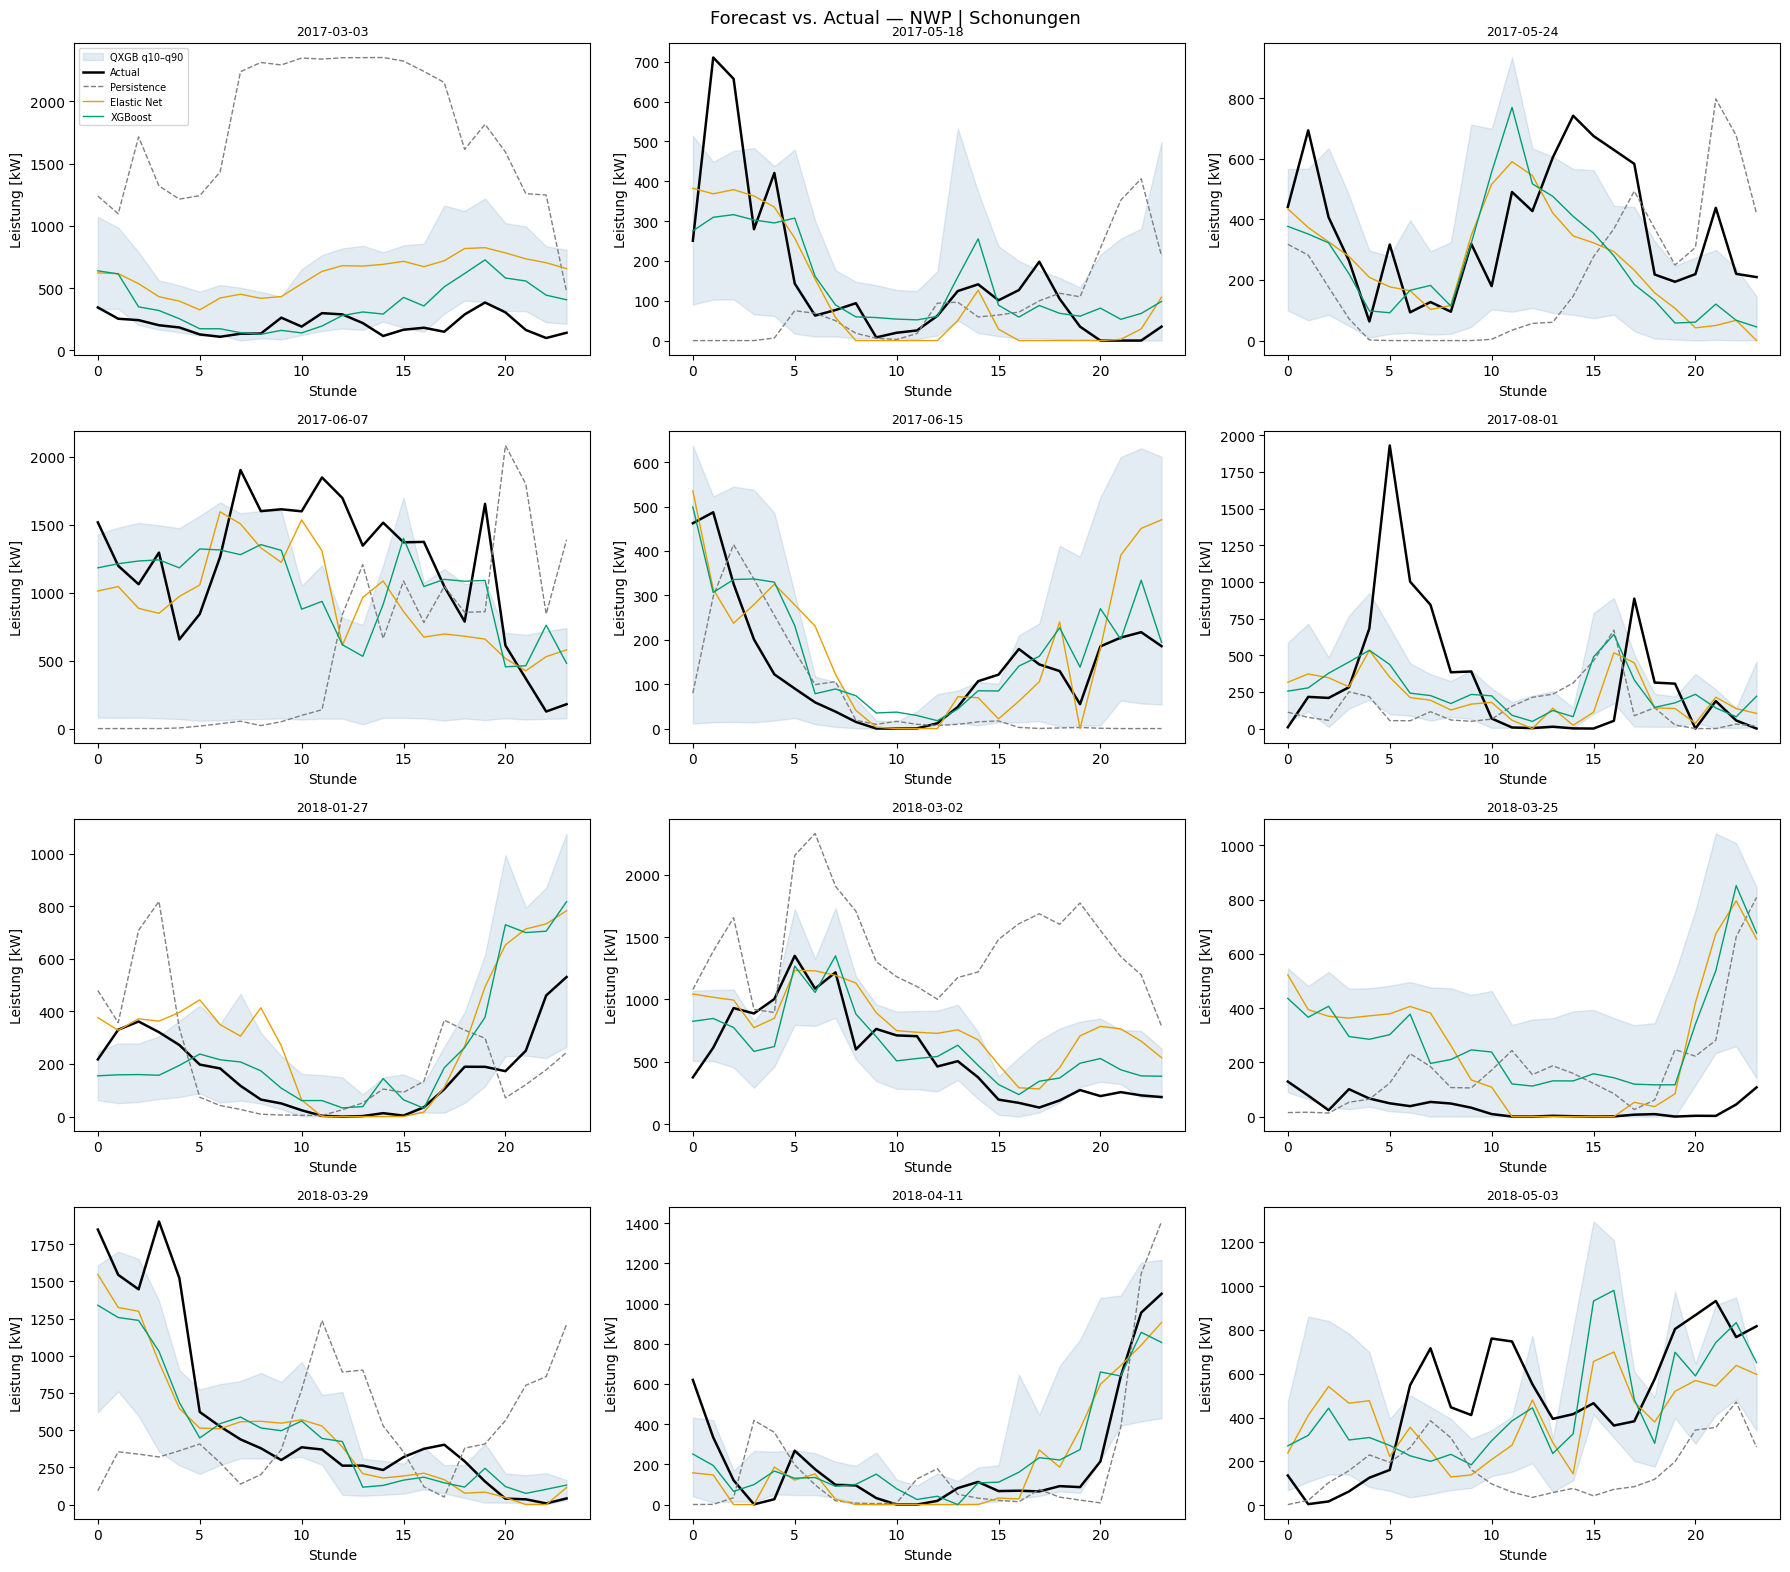

In [30]:
GRID_SCENARIO = "nwp"

day_order = list(TARGET_DAYS.keys())[:12]  # erste 12 Tage
n_cols = 3
n_rows = (len(day_order) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, day_label in enumerate(day_order):
    ax = axes[i]
    d = predictions_single_day[
        (predictions_single_day["day_label"] == day_label) &
        (predictions_single_day["scenario"]  == GRID_SCENARIO)
    ].sort_values("timestamp")

    if d.empty:
        ax.set_title(f"{day_label} (keine Daten)")
        continue

    hours = range(len(d))
    ax.fill_between(hours, d["qxgb_q10"], d["qxgb_q90"], alpha=0.15, color="steelblue", label="QXGB q10–q90")
    ax.plot(hours, d["y_true"],        color="black",      linewidth=1.8, label="Actual")
    ax.plot(hours, d["persistence_24h"], color="gray",     linestyle="--", linewidth=1, label="Persistence")
    ax.plot(hours, d["elastic_net"],   color="#E69F00",    linewidth=1, label="Elastic Net")
    ax.plot(hours, d["xgboost"],       color="#009E73",    linewidth=1, label="XGBoost")
    ax.set_title(day_label, fontsize=9)
    ax.set_xlabel("Stunde")
    ax.set_ylabel("Leistung [kW]")
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(day_order), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Forecast vs. Actual — {GRID_SCENARIO.upper()} | {SELECTED_PLANT}", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "forecast_vs_actual_grid_nwp.png", dpi=250, bbox_inches="tight")
plt.show()

## 14. Bias-Analyse: Systematische Über-/Unterschätzung

Zeigt für jedes Modell den mittleren Bias (y_pred - y_true) in beiden Szenarien.
Positiv = Modell überschätzt (overbid), Negativ = unterschätzt (underbid).
Relevant für Newsvendor-Bidding: ein stark verzerrtes Modell braucht ein angepasstes tau.

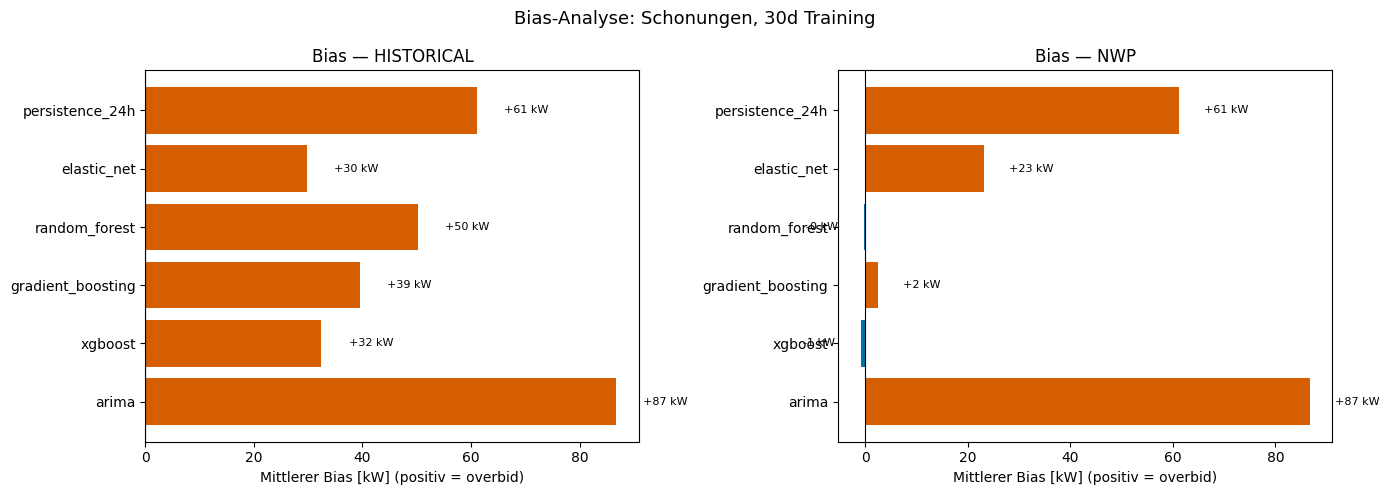

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, scenario in zip(axes, ["historical", "nwp"]):
    grp = point_metrics_single_day[point_metrics_single_day["scenario"] == scenario]
    grp = grp.set_index("model").reindex(POINT_MODEL_COLS).dropna()
    
    colors = ["#D55E00" if b > 0 else "#0072B2" for b in grp["Bias"]]
    bars = ax.barh(grp.index, grp["Bias"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    
    # Werte beschriften
    for bar, val in zip(bars, grp["Bias"]):
        ax.text(val + (5 if val >= 0 else -5), bar.get_y() + bar.get_height()/2,
                f"{val:+.0f} kW", va="center", ha="left" if val >= 0 else "right", fontsize=8)
    
    ax.set_title(f"Bias — {scenario.upper()}")
    ax.set_xlabel("Mittlerer Bias [kW] (positiv = overbid)")
    ax.invert_yaxis()

plt.suptitle(f"Bias-Analyse: {SELECTED_PLANT}, {TRAINING_WINDOW_DAYS}d Training", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bias_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Metriken-Übersicht: RMSE und R² im Vergleich

Kompakte Übersicht aller Modelle und Szenarien.

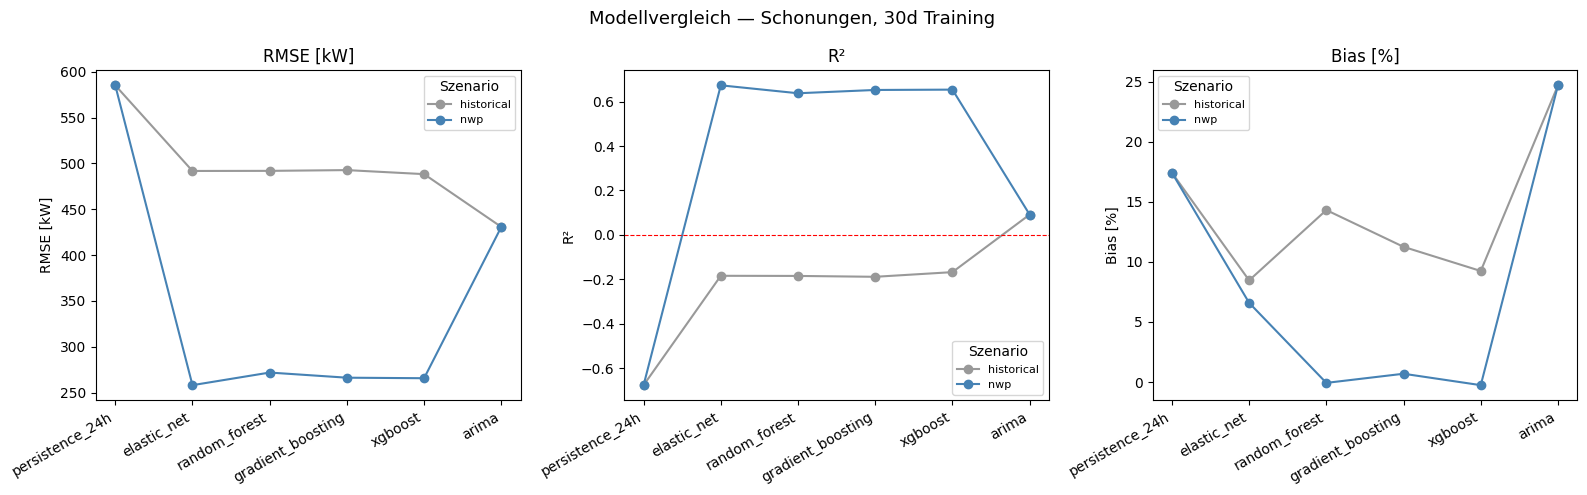

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [("RMSE", "RMSE [kW]", False), ("R2", "R²", True), ("Bias_pct", "Bias [%]", True)]

for ax, (metric, ylabel, higher_better) in zip(axes, metrics_to_plot):
    for scenario, grp in point_metrics_single_day.groupby("scenario"):
        grp_sorted = grp.set_index("model").reindex(POINT_MODEL_COLS).dropna()
        color = "steelblue" if scenario == "nwp" else "#999999"
        ax.plot(grp_sorted.index, grp_sorted[metric], marker="o",
                label=scenario, color=color, linewidth=1.5)
    
    ax.set_title(ylabel)
    ax.set_ylabel(ylabel)
    ax.legend(title="Szenario", fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    
    if metric == "R2":
        ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="R²=0")

plt.suptitle(f"Modellvergleich — {SELECTED_PLANT}, {TRAINING_WINDOW_DAYS}d Training", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "metrics_overview.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Scatter: Actual vs. Predicted

Zeigt wie gut das beste Modell (NWP) die tatsächliche Produktion trifft.
Punkte auf der Diagonalen = perfekte Vorhersage.

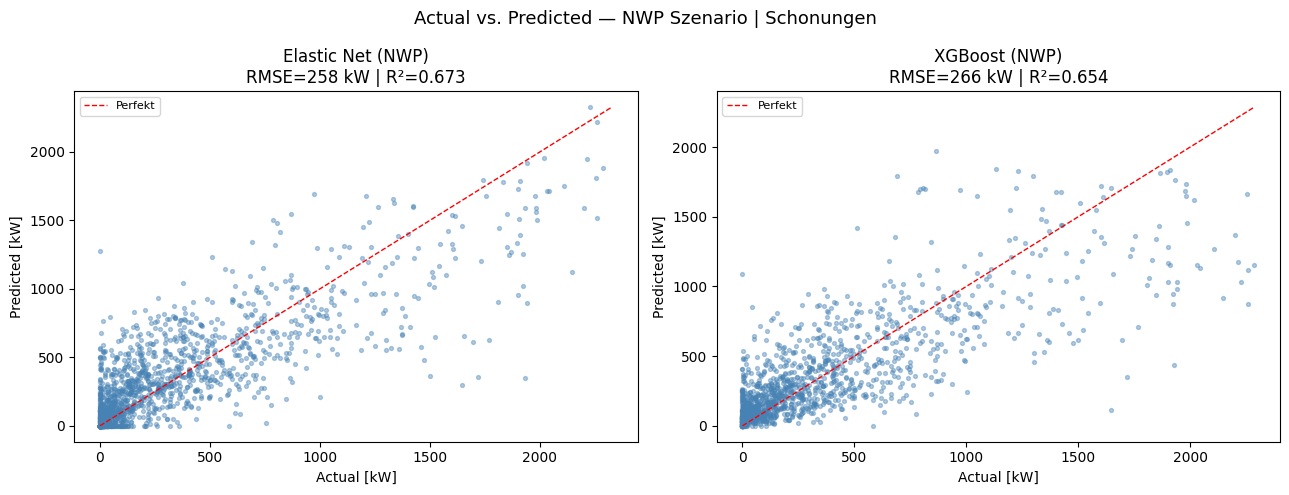

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

SCATTER_MODELS = [("elastic_net", "Elastic Net"), ("xgboost", "XGBoost")]

for ax, (col, label) in zip(axes, SCATTER_MODELS):
    d = predictions_single_day[predictions_single_day["scenario"] == "nwp"]
    valid = d[col].notna()
    y_t = d.loc[valid, "y_true"].values
    y_p = d.loc[valid, col].values
    
    ax.scatter(y_t, y_p, s=8, alpha=0.4, color="steelblue")
    
    # Diagonale (perfekte Vorhersage)
    lim = max(y_t.max(), y_p.max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="Perfekt")
    
    r2 = r2_score(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    ax.set_title(f"{label} (NWP)\nRMSE={rmse:.0f} kW | R²={r2:.3f}")
    ax.set_xlabel("Actual [kW]")
    ax.set_ylabel("Predicted [kW]")
    ax.legend(fontsize=8)

plt.suptitle(f"Actual vs. Predicted — NWP Szenario | {SELECTED_PLANT}", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Fehlerverteilung (Residuals)

Boxplot der stündlichen Fehler (y_pred - y_true) pro Modell im NWP-Szenario.
Zeigt nicht nur den mittleren Fehler, sondern auch die Streuung und Ausreißer —
relevant für die Quantilwahl in NB04.

/var/folders/4v/_vx6t4n16lb4q4h57475m_d40000gn/T/ipykernel_73776/184869242.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


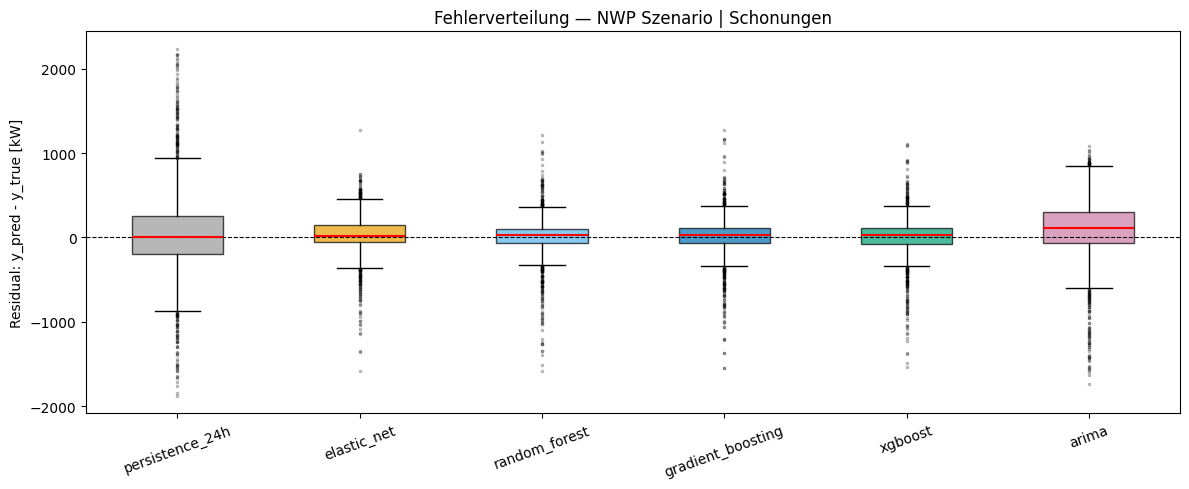

Interquartilsabstand (IQR) der Residuals:
  persistence_24h           IQR=453 kW
  elastic_net               IQR=207 kW
  random_forest             IQR=176 kW
  gradient_boosting         IQR=182 kW
  xgboost                   IQR=180 kW
  arima                     IQR=369 kW


In [34]:
d_nwp = predictions_single_day[predictions_single_day["scenario"] == "nwp"]

residuals = {}
for col in POINT_MODEL_COLS:
    valid = d_nwp[col].notna()
    if valid.sum() == 0:
        continue
    residuals[col] = (d_nwp.loc[valid, col] - d_nwp.loc[valid, "y_true"]).values

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    [residuals[m] for m in POINT_MODEL_COLS if m in residuals],
    labels=[m for m in POINT_MODEL_COLS if m in residuals],
    patch_artist=True,
    medianprops=dict(color="red", linewidth=1.5),
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
)

# Farben: interpretierbar vs. black-box
colors_box = {
    "persistence_24h": "#999999",
    "elastic_net": "#E69F00",
    "random_forest": "#56B4E9",
    "gradient_boosting": "#0072B2",
    "xgboost": "#009E73",
    "arima": "#CC79A7",
}
for patch, col in zip(bp["boxes"], [m for m in POINT_MODEL_COLS if m in residuals]):
    patch.set_facecolor(colors_box.get(col, "lightgray"))
    patch.set_alpha(0.7)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Residual: y_pred - y_true [kW]")
ax.set_title(f"Fehlerverteilung — NWP Szenario | {SELECTED_PLANT}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residual_boxplot_nwp.png", dpi=300, bbox_inches="tight")
plt.show()

print("Interquartilsabstand (IQR) der Residuals:")
for col, res in residuals.items():
    iqr = float(np.percentile(res, 75) - np.percentile(res, 25))
    print(f"  {col:<25} IQR={iqr:.0f} kW")